# **Predict Ames Homes Prices ---- Advanced Regression Technique**

<a id="section_ID"></a> <br>
 # Table of Contents
 1. [Introduction](#1)
    1. [Business Objective](#7)
    2. [Problem Statement](#8)
2. [Exploratory Data Anlaysis](#2)
   1. [Data Ingestion & Understanding](#7)
   2. [Univariate & Multivariate Feature Analysis](#8)

# __Introduction__

The Ames Housing dataset, created by Dean De Cock for educational use in data science, contains detailed records of residential property sales in Ames, Iowa between 2006 and 2010. It includes 2,919 observations and a rich set of eX_new_new_newplanatory variables: 23 nominal, 23 ordinal, 14 discrete, and 20 continuous features, all designed to capture the many factors that influence home values.

# Business Objective

In today's dynamic real estate market, accurate house price prediction is crucial for various stakeholders:
 - **Home Buyers** : Want to ensure making fair offers.
 - **Sellers** : Need to set compeitive listing prices.
 - **Real Estate Agents** : Need reliable price estimates to advise clinets effectively.
 - **Investors** : Require accurate valuation for investment decisions.

# Problem Statement
This project implements a machine learning solution to analyze various house dimensions to predict sale prices, helping stakeholders to make data-driven decisions.

# Import Libraries

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sidetable
import sklearn
import feature_engine
import scipy
import dvc 
import kaggle
import os
import zipfile
from pathlib import Path

%matplotlib inline
sns.set_style('darkgrid')


# Display Settings

In [110]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.float_format", '{:.2f}'.format)
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## Data Ingestion & Understanding

In [111]:
from pathlib import Path
import pandas as pd
files = []
path_data = Path.cwd().parent.joinpath("data", "raw")
for file in path_data.rglob("*.csv"):
    files.append(file)
    print(file.name)
    print(files.index(file), " ", file)

sample_submission.csv
0   e:\house_price_prediction\Real-Estate-Price-Prediction\data\raw\extracted\sample_submission.csv
test.csv
1   e:\house_price_prediction\Real-Estate-Price-Prediction\data\raw\extracted\test.csv
train.csv
2   e:\house_price_prediction\Real-Estate-Price-Prediction\data\raw\extracted\train.csv


In [112]:
# Load data
df_train = pd.read_csv(files[2], index_col='Id')
df_test = pd.read_csv(files[1], index_col='Id')

# Seperate features and target variable
X_train = df_train.drop(['SalePrice'], axis=1)
y = df_train.SalePrice

# Concatenate train and test data
X = pd.concat([X_new_new_new_new_new_new_new_new_new_new_new_new_new_train, df_test], axis=0)


In [113]:
X.shape

(2919, 79)

In [114]:
# Basic info of datasets
print(f"Training Dataset Shape : {X_train.shape}")
print(f"Testing Dataset Shape : {df_test.shape}")


Training Dataset Shape : (1460, 79)
Testing Dataset Shape : (1459, 79)


In [115]:
# remove whitespace from columns name, replace space to '_' for columns name for conveince

X_train.columns = X_train.columns.str.strip().str.replace(" ", "_").str.replace(".", "_")
df_test.columns = df_test.columns.str.strip().str.replace(" ", "_").str.replace(".", "_")

In [116]:
# Segregate numerical and categorical features
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
print(f"Total Numerical Columns : {len(num_cols)}\n", num_cols)

Total Numerical Columns : 36
 ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']


In [117]:
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()
print(f"Total Categorical Columns : {len(cat_cols)}\n", cat_cols)

Total Categorical Columns : 43
 ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


## **2. Exploratory Data Analysis**

#### **2.1. Sale Price**

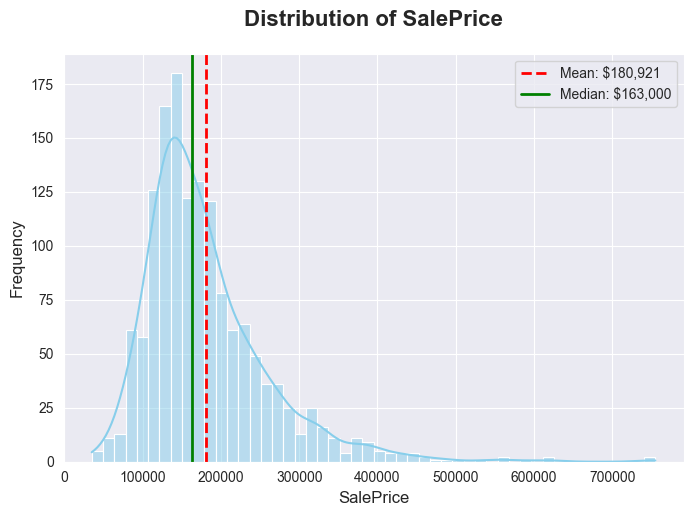

In [118]:
# Calculate statistics
mean_price = y.mean()
median_price = y.median()

# Plot histogram with KDE
fig = plt.figure(figsize=(8,6))
sns.histplot(y, kde=True, bins=50, color='skyblue')

# Add mean and median lines
plt.axvline(mean_price, color="red", linestyle="--", linewidth=2, label=f"Mean: ${mean_price:,.0f}")
plt.axvline(median_price, color="green", linestyle="-", linewidth=2, label=f"Median: ${median_price:,.0f}")

# Labels and legend
fig.subplots_adjust(bottom=0.2)
plt.title("Distribution of SalePrice", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("SalePrice", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend()
plt.show()

In [119]:
print(f"""Skewness : {y.skew():.4f}
Kurtosis : {y.kurtosis():.4f}""")

Skewness : 1.8829
Kurtosis : 6.5363


The distribution of `SalePrice` is right-skewed.

#### **2.2. Numerical Features**

Top 10 numerical features highly correlated with SalePrice:


In [169]:
corr_matrix = df_train.select_dtypes(include=[np.number]).corr()
top_10_corr = corr_matrix['SalePrice'].sort_values(ascending=False).head(11)
top_10_corr

SalePrice      1.00
OverallQual    0.79
GrLivArea      0.71
GarageCars     0.64
GarageArea     0.62
TotalBsmtSF    0.61
1stFlrSF       0.61
FullBath       0.56
TotRmsAbvGrd   0.53
YearBuilt      0.52
YearRemodAdd   0.51
Name: SalePrice, dtype: float64

__What are the top 10 features selected by Recursive Feature Elimination?__


In [121]:
from sklearn.feature_selection import RFE, f_regression, r_regression
from sklearn.linear_model import LinearRegression

model = LinearRegression()
rfe = RFE(estimator=model, n_features_to_select=10, step=1)
selector = rfe.fit(X_train.fillna(0).select_dtypes(exclude='object'), y)
selected_features = list(
    X_train.select_dtypes(exclude='object').columns[selector.support_]
)
selected_features

['OverallQual',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageCars']

Based on the analyses, features such as __Overall Quality, Living Area, Garage Size, Number of Full Baths, and Year Built__ emerge as key determinants of house prices. Let's explore these features in greater detail.

**Overall Quality**

Overall quality is the most important feature in both analyses. It is clear that higher quality makes the house more expensive.



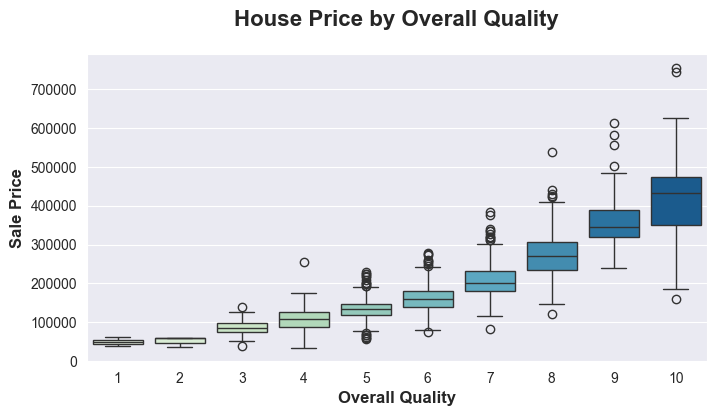

In [122]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(x='OverallQual', y='SalePrice', data=df_train, palette='GnBu')
ax.set_title('House Price by Overall Quality', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Overall Quality', fontsize=12, fontweight='bold')
ax.set_ylabel('Sale Price', fontsize=12, fontweight='bold')
plt.show()


#### **Living Area**

The living area shows a clear linear relationship with house price. In the scatter plot, however, several __outliers__ are evident—most notably two properties in the lower-right corner with more than __4,000 square feet__ of living space but priced below __$200,000__.

Correlation : 0.7086244776126515


<Figure size 600x400 with 0 Axes>

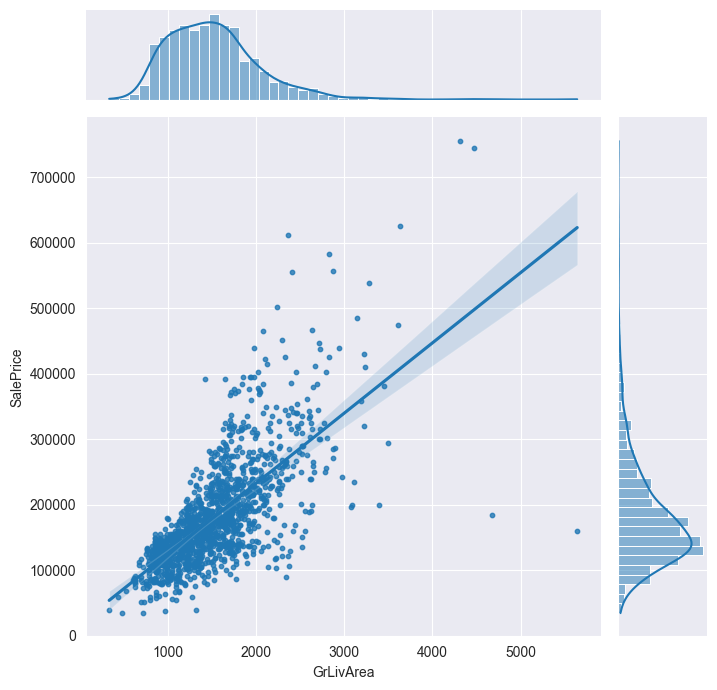

In [123]:
def plot_correlation(features):
    """
    1. Plot correlation of two features
    2. Create Joint plot of two features
    """
    # print correlation
    print("Correlation :", df_train[[features[0], features[1]]].corr().iloc[1, 0])

    # Create joint plot
    plt.figure(figsize=(6, 4))
    sns.jointplot(data = df_train, x= features[0], y=features[1], kind='reg', height=7, scatter_kws={'s': 10}, marginal_kws={'kde': True})
    

plot_correlation(['GrLivArea', 'SalePrice'])
plt.show()

#### **GarageCars**

It's surprising that houses with __four-car garages__ are actually priced lower than those with __three-car garages__.

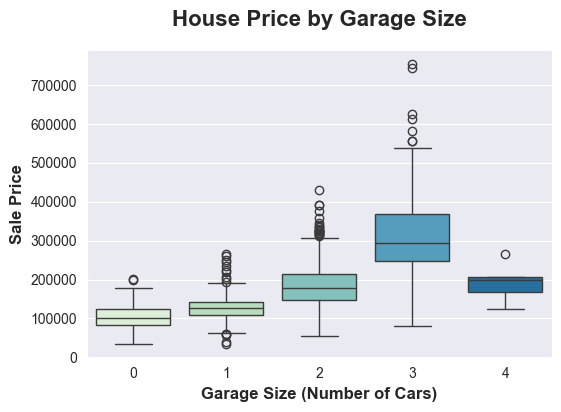

In [124]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(x='GarageCars', y='SalePrice', data=df_train, palette='GnBu', ax=ax)
ax.set_title('House Price by Garage Size', fontdict={'fontsize': 16, 'fontweight': 'bold'}, y=1.05)
ax.set_xlabel('Garage Size (Number of Cars)', fontsize=12, fontweight='bold')
ax.set_ylabel('Sale Price', fontsize=12, fontweight='bold')
plt.show()


#### **Year Built**

The age of a house is another key factor influencing its price. In general, newer homes command higher average values, though there are also several pre‑1900 properties that stand out with notably high prices.

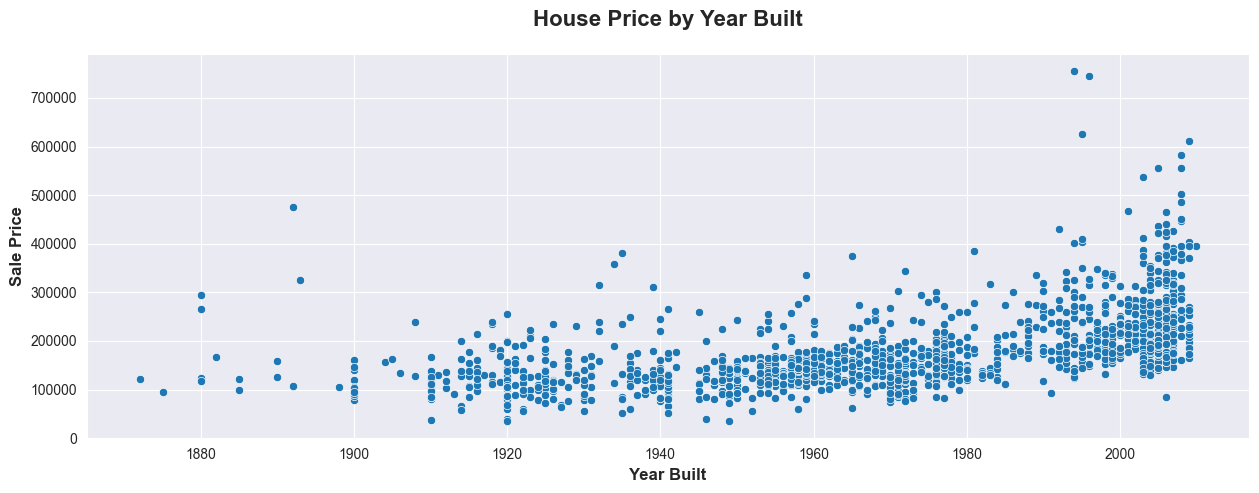

In [125]:
fig, ax = plt.subplots(figsize=(15, 5))
sns.scatterplot(x='YearBuilt', y='SalePrice', data=df_train, ax=ax)
ax.set_title('House Price by Year Built', fontdict={'fontsize': 16, 'fontweight': 'bold'}, y=1.05)
ax.set_xlabel('Year Built', fontsize=12, fontweight='bold')
ax.set_ylabel('Sale Price', fontsize=12, fontweight='bold')
plt.show()


#### **2.3. Categorical Variables**

In [126]:
from sklearn.preprocessing import LabelEncoder
from scipy import stats
# Select Categorical features
cat_columns = df_train.select_dtypes(include='object').columns
target_data = df_train['SalePrice']

# store results
results = []

for col in cat_columns:
    # Group the numerical data by the categorical column
    groups = [target_data[df_train[col] == category] for category in df_train[col].unique()]
    # Perform ANOVA test
    f_value, p_value = stats.f_oneway(*groups)
    # Append the results to the list
    results.append({
        'Feature': col,
        'F_value': f_value,
        'P_value': p_value
    })
# Create a DataFrame from the results
results_df = pd.DataFrame(results)
# Sort the DataFrame by F_value and P_value in descending order
results_df = results_df.sort_values(by=['F_value'], ascending=False).reset_index(drop=True)
# select top 15 features
top_features = results_df[results_df['P_value'] < 0.01].head(1)
print(top_features)

C:\Users\Admin\AppData\Local\Temp\ipykernel_15728\1279778541.py:14: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f_value, p_value = stats.f_oneway(*groups)


     Feature  F_value  P_value
0  ExterQual   443.33     0.00


In [127]:
import pandas as pd
from scipy.stats import f_oneway

# Target variable
y = df_train["SalePrice"]

# Identify categorical features
categorical_features = df_train.select_dtypes(include=["object"]).columns

anova_results = []

# Perform one-way ANOVA for each categorical feature
for col in categorical_features:
    groups = []
    for category in df_train[col].dropna().unique():
        groups.append(y[df_train[col] == category])
    
    # Run ANOVA only if there are at least 2 groups
    if len(groups) > 1:
        f_stat, p_val = f_oneway(*groups)
        anova_results.append((col, f_stat, p_val))

# Convert to DataFrame
anova_df = pd.DataFrame(anova_results, columns=["Feature", "F-Statistic", "p-value"])

# Filter features with p-value < 0.01
significant_features = anova_df[anova_df["p-value"] < 0.01]

# Sort by p-value and select top 15
top_15 = significant_features.sort_values("F-Statistic", ascending=False).reset_index(drop=True).head(1)

print(top_15)


     Feature  F-Statistic  p-value
0  ExterQual       443.33     0.00


In [128]:
set(top_15['Feature']).intersection(set(top_features['Feature']))

{'ExterQual'}

In [129]:
# Separate target and features
X_df = df_train.drop(columns=["SalePrice"])
y = df_train["SalePrice"]

# Encode categorical variables numerically
X_encoded = X_df.select_dtypes(include=["object"]).copy()
for col in X_encoded.columns:
    X_encoded[col] = LabelEncoder().fit_transform(X_encoded[col].astype(str))

# Handle missing values (fill with median for numeric, mode for categorical)
for col in X_encoded.columns:
    if X_encoded[col].dtype == "object":
        X_encoded[col].fillna(X_encoded[col].mode()[0], inplace=True)
    else:
        X_encoded[col].fillna(X_encoded[col].median(), inplace=True)

# Run ANOVA F-test (linear regression method)
f_stats, p_values = f_regression(X_encoded, y)

# Create DataFrame of results
anova_results = pd.DataFrame({
    "Feature": X_encoded.columns,
    "F-Statistic": f_stats,
    "p-value": p_values
})

# Sort by p-value and select top 15
top_var = anova_results#.sort_values("p-value")#.head(15)
top_var = top_var[top_var["p-value"] < 0.01].sort_values("F-Statistic", ascending=False).reset_index(drop=True).head(1)
print(top_var)

     Feature  F-Statistic  p-value
0  ExterQual       994.98     0.00


In [130]:
len(set(top_var['Feature']).intersection(set(top_15['Feature'])))

1

In [131]:
print(len(set(top_var['Feature']).intersection(set(top_15['Feature']))))
print(len(set(top_15['Feature']).intersection(set(top_features['Feature']))))
print(len(set(top_var['Feature']).intersection(set(top_features['Feature']))))

1
1
1


#### **2.4. Correlations**

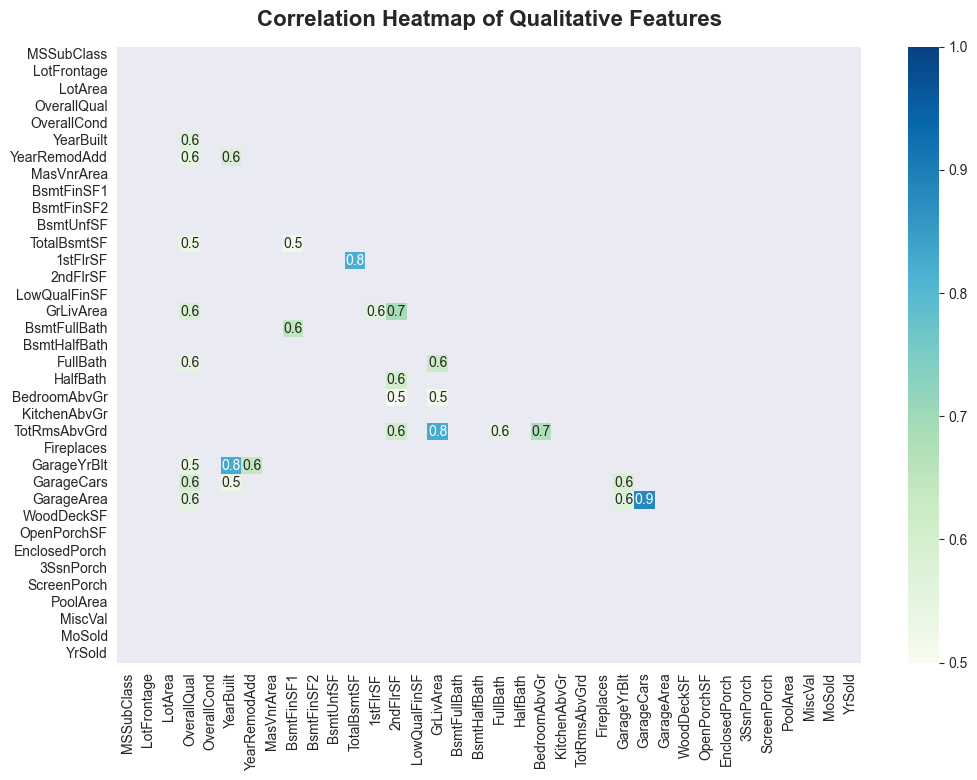

In [132]:
# Create correlation matrix from train data excluding `SalePrice`
corr_mat = df_train.iloc[:, :-1].select_dtypes(include=[np.number]).corr()

# Select correlations greater than 0.5
high_corr_mat = corr_mat[abs(corr_mat) >= 0.5]

# Plot correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(high_corr_mat,mask = np.triu(np.ones_like(high_corr_mat, dtype=bool)),
            annot=True,
            fmt='.1f',
            cmap='GnBu',
            vmin=0.5,
            vmax=1)
plt.title('Correlation Heatmap of Qualitative Features', fontsize=16, fontweight='bold', y=1.02)
plt.grid(False)
plt.show()


Our training data shows evidence of multicollinearity, with several features exhibiting strong correlations with one another.
- GarageCars and GarageArea
- GarageYrBlt and YearBuilt
- 1stFlrSF and TotalBsmtSF
- GrLivArea and TotRmsAbvGrd

Multicollinearity negatively affects prediction models by increasing the standard errors of estimates. To address this, for each pair of highly correlated features,  will remove the one that shows a weaker correlation with `SalePrice`.

#### **2.5. Missing Values**

Most machine learning algorithms cannot be trained directly on datasets containing missing values. That’s why it’s crucial to detect them first and then decide whether to drop the affected features or impute the missing entries.

        Features  missing  total  percent columns_dtype
0         PoolQC     2909   2919    99.66        object
1    MiscFeature     2814   2919    96.40        object
2          Alley     2721   2919    93.22        object
3          Fence     2348   2919    80.44        object
4     MasVnrType     1766   2919    60.50        object
5    FireplaceQu     1420   2919    48.65        object
6    LotFrontage      486   2919    16.65       float64
7     GarageCond      159   2919     5.45        object
8   GarageFinish      159   2919     5.45        object
9    GarageYrBlt      159   2919     5.45       float64
10    GarageQual      159   2919     5.45        object
11    GarageType      157   2919     5.38        object
12  BsmtExposure       82   2919     2.81        object
13      BsmtCond       82   2919     2.81        object
14      BsmtQual       81   2919     2.77        object


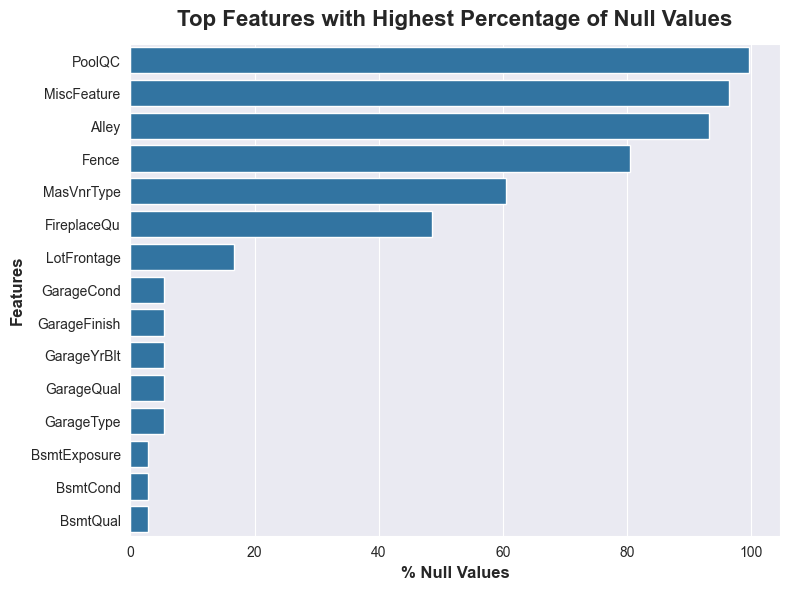

In [133]:
def plot_null_counts(df: pd.DataFrame, top_n: int = 15) -> pd.DataFrame: 
    null_info = df.stb.missing().reset_index().rename({'index':'Features'},axis='columns').sort_values(by='percent',ascending=False)
    null_info['columns_dtype'] = [df[col].dtype for col in null_info['Features']]

    null_info = null_info.loc[null_info['missing']>0].head(top_n)
    print(null_info)

    plt.figure(figsize=(8,6))
    sns.barplot(x='percent', y='Features',data=null_info)
    plt.title('Top Features with Highest Percentage of Null Values', fontsize=16, fontweight='bold', y=1.02)
    plt.xlabel('% Null Values', fontsize=12, fontweight='bold')
    plt.ylabel('Features', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    return 

plot_null_counts(X)


#### **Outlier Analysis**

Lets look at percentage of possible outliers in numerical features.

In [143]:
"""
Calculate the percentage of outliers based on winsorization method for all the numerical features in the DataFrame.

Parameters:
df(pd.DataFrame): The input DataFrame containing numerical features.
lower_percentile(float): The lower percentile foe winsorization. Default is 5.
upper_percentile(float): The upper percentile for winsorization. Default is 95.

Returns:
pd.DataFrame : A DataFrame containing the columns name and percentage of outliers for each numerical features.
"""

#numeric_df = df_train[df_train.columns.difference(['SalePrice'])]
numeric_df = X.select_dtypes(include='number')
outliers_percentages = {}
for col in numeric_df.columns:
    x_low, x_high = np.percentile(numeric_df[col].dropna(),[1,99])
    total_values = len(numeric_df[col])
    outliers = len(numeric_df[~numeric_df[col].between(x_low,x_high)])
    outliers_percentage = round((outliers / total_values)*100 , 2)
    outliers_percentages[col] = outliers_percentage
    
outliers_df = pd.DataFrame(list(outliers_percentages.items()), columns=['Features','Outliers Percentage'])
outliers_data = outliers_df.sort_values(by='Outliers Percentage', ascending=False).reset_index(drop=True)
outliers_data.head(10)



,Features,Outliers Percentage
0,LotFrontage,17.51
1,GarageYrBlt,6.41
2,GrLivArea,2.06
3,1stFlrSF,2.02
4,YearBuilt,1.85
5,MasVnrArea,1.78
6,LotArea,1.68
7,TotRmsAbvGrd,1.54
8,BsmtFinSF2,1.06
9,GarageArea,1.06


With some basic understandings of the data set and features, let's do data preprocessing and modeling steps.




## **3. Data Preprocessing and Feature Engineering**

#### **3.1 Missing Values Treatment**

In [135]:
missing_df = X.stb.missing()
missing_df['columns_dtype'] = [X[col].dtype for col in missing_df.index]
missing_df['unique_value'] = [X[col].unique() for col in missing_df.index]
missing_df['nunique_value'] = [X[col].nunique() for col in missing_df.index]
missing_df = missing_df.query("percent > 0")
print(f"There are {len(missing_df.index)} features with missing data.\n")
print(missing_df.head(10))

There are 34 features with missing data.

              missing  total  percent columns_dtype  \
PoolQC           2909   2919    99.66        object   
MiscFeature      2814   2919    96.40        object   
Alley            2721   2919    93.22        object   
Fence            2348   2919    80.44        object   
MasVnrType       1766   2919    60.50        object   
FireplaceQu      1420   2919    48.65        object   
LotFrontage       486   2919    16.65       float64   
GarageCond        159   2919     5.45        object   
GarageFinish      159   2919     5.45        object   
GarageYrBlt       159   2919     5.45       float64   

                                                   unique_value  nunique_value  
PoolQC                                        [nan, Ex, Fa, Gd]              3  
MiscFeature                       [nan, Shed, Gar2, Othr, TenC]              4  
Alley                                         [nan, Grvl, Pave]              2  
Fence                       

There are 34 features that have missing values. Will divide them into three groups based on the data description and percentage:

- **Group 1 - Categorical variables where NA means no feature:** 
PoolQC, MiscFeature, Alley, Fence, FireplaceQu, GarageType, GarageFinish, GarageQual, GarageCond, BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinType2, MasVnrType (15 variables)

    For group1, will impute `NA` with `None`.

- **Group 2 - Numerical variables where NA means no feature:**
GarageArea, GarageCars, BsmtFinSF1, BsmtFinSF2, BsmtUnfSF, TotalBsmtSF, BsmtFullBath, BsmtHalfBath, MasVnrArea, GarageYrBlt (9 variables)

    For group2, will impute `NA` with 0.

- **Group 3 - Other variables:** 
Functional, MSZoning, Electrical, KitchenQual, Exterior1st, Exterior2nd, SaleType, Utilities, LotFrontage, GarageYrBlt (10 variables)

    -  will impute Functional, MSZoning, Electrical, KitchenQual, Exterior1st, Exterior2nd, SaleType, Utilities with their modes,
    - impute LotFrontage with its mean.
    - impute GarageYrBlt with YearBuilt.



In [137]:
from sklearn.impute import SimpleImputer
X_new = X.copy()
# Group 1:
group_1 = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'GarageType',
    'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond',
    'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType'
]
X_new[group_1] = X_new[group_1].fillna("None")

# Group 2:
group_2 = [
    'GarageArea', 'GarageCars', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
    'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea'
]

X_new[group_2] = X_new[group_2].fillna(0)

# Group 3:
group_3a = [
    'Functional', 'MSZoning', 'Electrical', 'KitchenQual', 'Exterior1st',
    'Exterior2nd', 'SaleType', 'Utilities'
]

imputer = SimpleImputer(strategy='most_frequent')
X_new[group_3a] = pd.DataFrame(imputer.fit_transform(X_new[group_3a]), index=X.index)

X_new['LotFrontage'] = X_new['LotFrontage'].fillna(X_new['LotFrontage'].mean())
X_new['GarageYrBlt'] = X_new['GarageYrBlt'].fillna(X_new['YearBuilt'])


In [138]:
# Check whether there is any missing data left:
X_new.isnull().sum().sum()

np.int64(0)

All missing values have been handled.




#### **3.2 Outliers Treatment**

Because regression models are very sensitive to outlier, we need to be aware of them. Let's examine outliers with a scatter plot.



In [161]:
outliers_data.head(10)

,Features,Outliers Percentage
0,1stFlrSF,2.02
1,GrLivArea,2.02
2,YearBuilt,1.85
3,LotArea,1.68
4,OverallQual,1.58
5,TotRmsAbvGrd,1.51
6,OpenPorchSF,1.03
7,LotFrontage,1.03
8,BsmtUnfSF,1.03
9,TotalBsmtSF,1.03


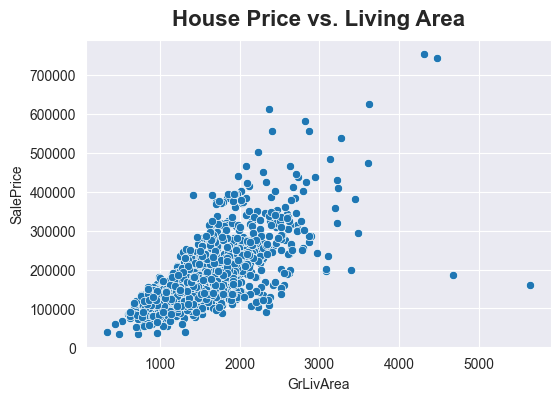

In [165]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df_train, ax=ax)
ax.set_title('House Price vs. Living Area', fontsize=16, fontweight='bold', y=1.02)
plt.show()


There are two observations lying separately from the rest. They have large living area but low price. They are the outliers that we are looking for. Will delete them from the training set.


In [159]:
outlier_index = df_train[(df_train.GrLivArea > 4000)
                           & (df_train.SalePrice < 200000)].index
X_new.drop(outlier_index, axis="index", inplace=True)
y.drop(outlier_index, axis="index", inplace=True)



#### **3.3. Feature Engineering**



##### **3.3.1. Create New Variables**

In this step I will create new features from weaker features in the training data. For example, the surface area of each floor has low correlation with house price; however, when we sum them up, the relationship becomes much stronger. In fact, __TotalSqFeet becomes the strongest feature in the dataset. The new features I will create are total square feet, total number of bathrooms, age of the house, whether the house was remodeled, and whether the house was sold in the same year it was built.__



In [172]:
X_new['totalSqFeet'] = X_new['TotalBsmtSF'] + X_new['1stFlrSF'] + X_new['2ndFlrSF']
X_new['totalBathroom'] = X_new['FullBath'] + X_new['BsmtFullBath'] + 0.5 * (X_new['HalfBath'] + X_new['BsmtHalfBath'])
X_new['houseAge'] = X_new['YrSold'] - X_new['YearBuilt']
X_new['reModeled'] = np.where(X_new['YearRemodAdd'] == X_new['YearBuilt'], 0, 1)
X_new['isNew'] = np.where(X_new['YrSold'] == X_new['YearBuilt'], 1, 0)



##### **3.3.2. Label Encoding**

Ordinal categorical features are label encoded.



In [174]:
from sklearn.preprocessing import LabelEncoder

# Ordinal categorical columns
label_encoding_cols = [
    "Alley", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "BsmtQual", "ExterCond", "ExterQual", "FireplaceQu", "Functional",
    "GarageCond", "GarageQual", "HeatingQC", "KitchenQual", "LandSlope",
    "LotShape", "PavedDrive", "PoolQC", "Street", "Utilities"
]

# Apply Label Encoder
label_encoder = LabelEncoder()

for col in label_encoding_cols:
    X_new[col] = label_encoder.fit_transform(X_new[col])



##### **3.3.3. Transform Numerical Variables to Categorical Variables**

Because I have calculated age of houses, YearBuilt is no longer needed. However, YrSold could have a large impact on house price (e.g. In economic crisis years, house price could be lower). Therefore, I will transform it into categorical variables.

Like YrSold, some numerical variables don't have any ordinal meaning (e.g. MoSold, MSSubClass). I will transform them into categorical variables.


In [177]:
to_factor_cols = ['YrSold', 'MoSold', 'MSSubClass']

for col in to_factor_cols:
    X_new[col] = X_new[col].apply(str)



##### __3.4. Skewness and Normalizing Variables__

Normal distribution is one of the assumption that linear regression relies on. Therefore, transfoming skewed data will help our models perform better.

First, let's examine the target variable `SalePrice` with Distribution plot and Quantile-Quantile plot.

__Target variable__



In [178]:
from scipy.stats import norm

def normality_plot(X):
    """
    1. Draw distribution plot with normal distribution fitted curve
    2. Draw Quantile-Quantile plot 
    """
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    sns.distplot(X, fit=norm, ax=axes[0])
    axes[0].set_title('Distribution Plot')

    axes[1] = stats.probplot((X), plot=plt)
    plt.tight_layout()


C:\Users\Admin\AppData\Local\Temp\ipykernel_15728\1449569438.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X, fit=norm, ax=axes[0])


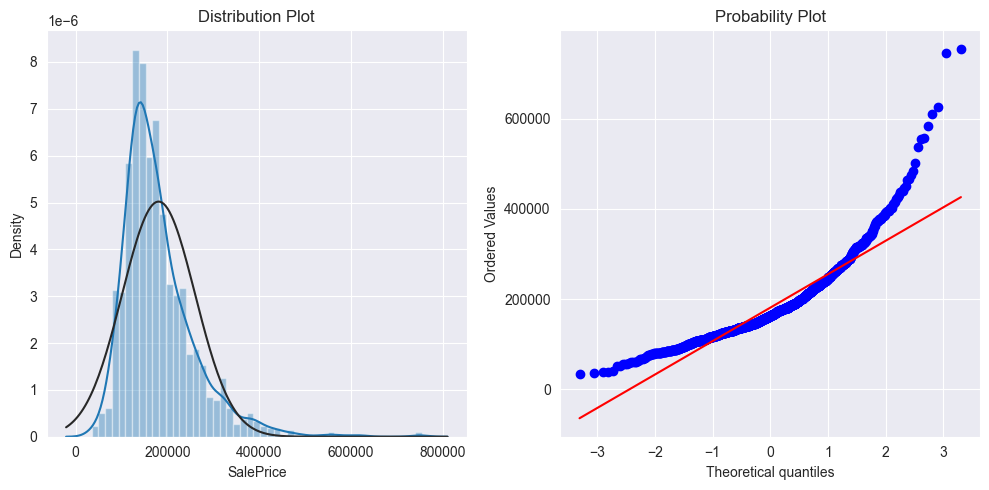

In [179]:
normality_plot(y)


One of the methods to normalize right-skewed data is using log transformation because big values will be pulled to the center. However, log(0) is Nan, so I will use log(1+X) to fix skewness instead.



In [185]:
y_new = np.log(1 + y) 


And this is `SalePrice` after log transformation. The sknewness has been fixed.



C:\Users\Admin\AppData\Local\Temp\ipykernel_15728\1449569438.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X, fit=norm, ax=axes[0])


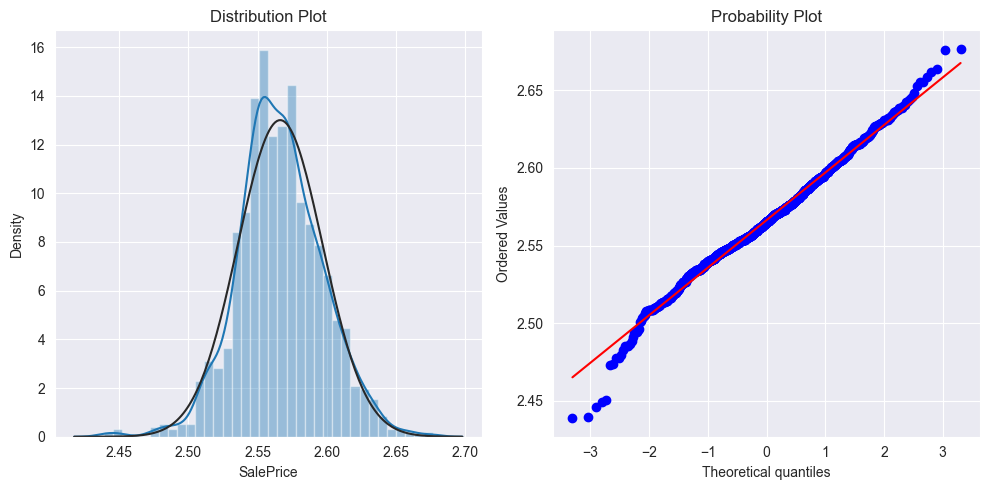

In [186]:
normality_plot(y_new)


In the next step, I will examine skewness in the rest of numerical features and use transformation to fix them.



__Fixing skewness in other numerical variables__

If skewness is less than -1 or greater than 1, the distribution is __highly skewed__.

If skewness is between -1 and -0.5 or between 0.5 and 1, the distribution is __moderately skewed__.

If skewness is between -0.5 and 0.5, the distribution is __approximately symmetric__.

Below are skewed features in our original train data.



In [190]:
skewness = X_new[num_cols].skew().sort_values(ascending=False)
skewness[abs(skewness) > 0.75]


MiscVal         21.95
PoolArea        17.70
LotArea         13.12
LowQualFinSF    12.09
3SsnPorch       11.38
KitchenAbvGr     4.30
BsmtFinSF2       4.15
EnclosedPorch    4.00
ScreenPorch      3.95
BsmtHalfBath     3.93
MasVnrArea       2.62
OpenPorchSF      2.53
WoodDeckSF       1.85
MSSubClass       1.38
1stFlrSF         1.26
LotFrontage      1.23
GrLivArea        1.07
BsmtFinSF1       0.98
BsmtUnfSF        0.92
2ndFlrSF         0.86
dtype: object

Let's check normality of GrLivArea:



C:\Users\Admin\AppData\Local\Temp\ipykernel_15728\1449569438.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X, fit=norm, ax=axes[0])


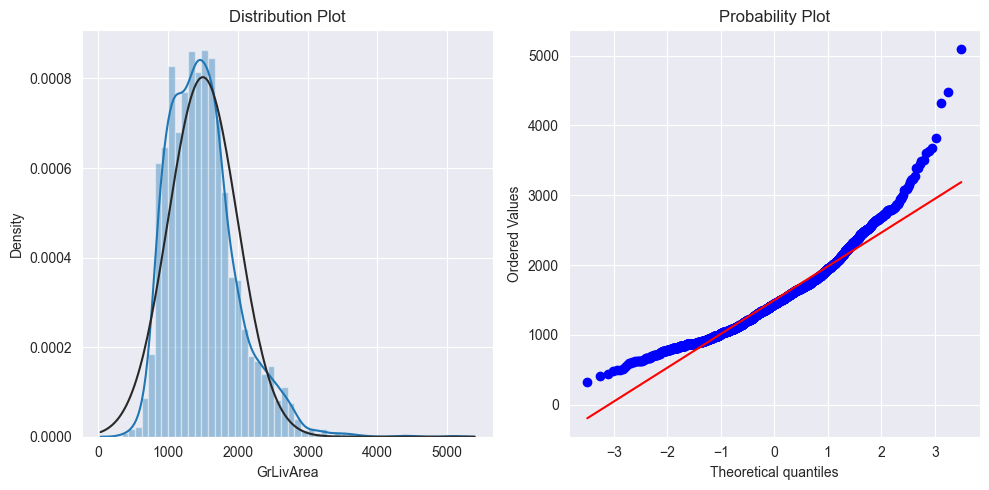

In [191]:
normality_plot(X_new['GrLivArea'])


In [ ]:
# List of skewed columns
skewed_cols = list(skewness[abs(skewness) > 0.5].index)

# Remove 'MSSubClass' and 'SalePrice'
skewed_cols = [
    col for col in skewed_cols if col not in ['MSSubClass', 'SalePrice']
]

# Log-transform skewed columns
for col in skewed_cols:
    X_new[col] = np.log(1 + X_new[col])


Below is normality of GrLivArea after log-transformation. Skewness has been fixed.



C:\Users\Admin\AppData\Local\Temp\ipykernel_15728\1449569438.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X, fit=norm, ax=axes[0])


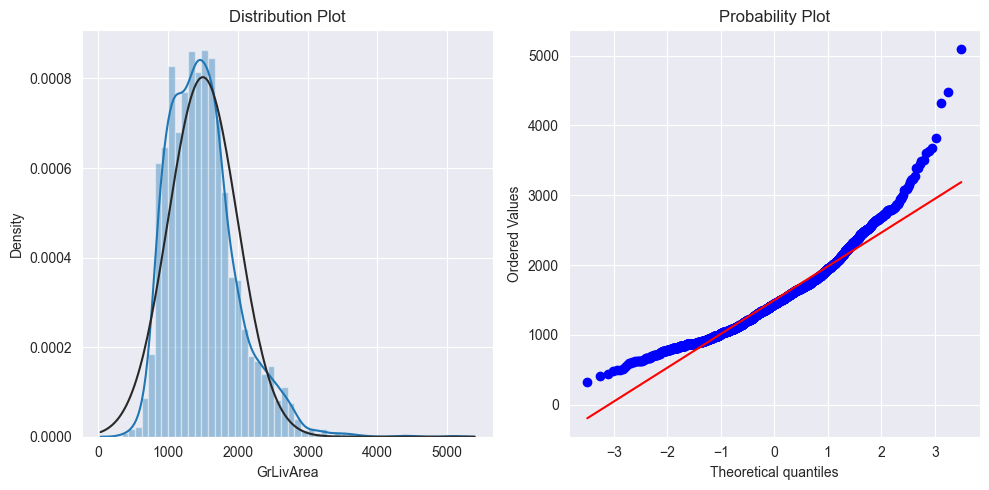

In [192]:
normality_plot(X_new['GrLivArea'])


##### **3.5. Feature Scaling**

Except for Decision Tree and Random Forest, it is highly recommended to standardize the data set before running machine learning algorithms since optimization methods and gradient descent run and converge faster on similarly scaled features.

However, outliers can often influence the sample mean and standard deviation in a negative way, and models like Lasso and Elastic Net are very sensitive to outliers. In such cases, the median and the interquartile range often give better results. I will use RobustScaler to transform the training data.



In [193]:
from sklearn.preprocessing import RobustScaler
numerical_cols = list(X_new.select_dtypes(exclude=['object']).columns)
scaler = RobustScaler()
X_new[numerical_cols] = scaler.fit_transform(X_new[numerical_cols])



**3.6. One-hot Encoding**


In [194]:
X_new = pd.get_dummies(X_new, drop_first=True)
print("X.shape:", X_new.shape)


X.shape: (2917, 237)


After preprocessing the train and test data, I split them again to perform modeling.



In [195]:
ntest = len(df_test)
X_train = X_new.iloc[:-ntest, :]
X_test = X_new.iloc[-ntest:, :]
print("X_train.shape:", X_train.shape)
print("X_test.shape:", X_test.shape)


X_train.shape: (1458, 237)
X_test.shape: (1459, 237)


zf = zipfile.ZipFile('E://house_price_prediction//Real-Estate-Price-Prediction//data//raw//house-prices-advanced-regression-techniques.zip') 
submission = pd.read_csv(zf.open('sample_submission.csv'))
test = pd.read_csv(zf.open('test.csv'))
train = pd.read_csv(zf.open('train.csv'))
description = pd.read_csv(zf.open('data_description.txt'),sep='\t',on_bad_lines='skip')

print(zf.namelist())

description

with zipfile.ZipFile('e:/house_price_prediction/Real-Estate-Price-Prediction/data/raw/zipped/house-prices-advanced-regression-techniques.zip','r') as zip_file:
    file_list = zip_file.namelist()
    print('The File List are :', file_list)

import logging
from zipfile import ZipFile
from pathlib import Path

#Extract all zipped files
def extract_all_file(input_path: Path, output_path: Path):
    with ZipFile(file= input_path) as f:
        f.extractall(path= output_path)

def main():
    #current file path 
    current_path = Path(__file__)
    #root directory path
    root_path = current_path.parent.parent.parent
    #raw data directory path
    raw_data_path = root_path / 'data' / 'raw'
    #output path for the zip files
    output_path = raw_data_path / 'extracted'
    #make the directory for the path
    output_path.mkdir(parents=True,exist_ok=True)
    #input path for zip files
    input_path = raw_data_path / 'zipped'

    


#Extract all files
extract_all_file(input_path = input_path,#/'house-prices-advanced-regression-techniques.zip',
                 output_path = output_path)

#call the main function
if __name__ == '__main__':
    main()

